In [ ]:
import math
import random

In [ ]:
class Value:
  def __init__(self, data, _children=(), _op='', label=''):
    self.data = data
    self.grad = 0
    self._backward = lambda: None
    self.label = label
    self._prev = set(_children)
    self._op = _op

  def __repr__(self):
    return f'Value(data={self.data})'

  def __add__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data + other.data, (self, other), '+')

    def _backward():
      self.grad += 1 * out.grad
      other.grad += 1 * out.grad

    out._backward = _backward
    return out

  def __radd__(self, other): # other + self
    return self + other

  def __neg__(self): # -self
    return self * -1

  def __sub__(self, other): # self - other
    return self + (-other)

  def __mul__(self, other):
    other = other if isinstance(other, Value) else Value(other)
    out = Value(self.data * other.data, (self, other), '*')

    # backpropagation - We are calculating how change in self and other will impact final output o
    # We already calculated how change in out will impact final output o
    # Now using chain rule - impact of change in self on final output = impact of change in self on out * impact of change in out on final output
    def _backward():
      self.grad += other.data * out.grad
      other.grad += self.data * out.grad

    out._backward = _backward
    return out

  def __rmul__(self, other): # other * self
    return self * other

  def __pow__(self, other):
    assert isinstance(other, (int, float)), "only supporting int/float powers for now"
    out = Value(self.data**other, (self,), f'**{other}')

    def _backward():
        self.grad += other * (self.data ** (other - 1)) * out.grad
    out._backward = _backward
    return out

  def tanh(self):
    # https://en.wikipedia.org/wiki/Hyperbolic_functions

    x = self.data
    t = (math.exp(2*x) - 1)/(math.exp(2*x) + 1)
    out = Value(t, (self, ), 'tanh')

    def _backward():
      self.grad = (1 - (t**2)) * out.grad # chain rule

    out._backward = _backward
    return out

  def backward(self):

    topo_order = []
    visited = set()

    def build_topo(node):
      if node not in visited:
        visited.add(node)
        for child in node._prev:
          build_topo(child)
      topo_order.append(node)

    build_topo(self)

    self.grad = 1.0
    for node in reversed(topo_order):
      node._backward()




In [ ]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right

  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

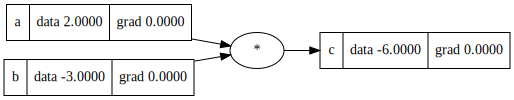

In [ ]:
# Test graph representation

a = Value(2.0, label ='a')
b = Value(-3.0, label = 'b')
c = a * b # a.__mul__(b)
c.label='c'

c
draw_dot(c)

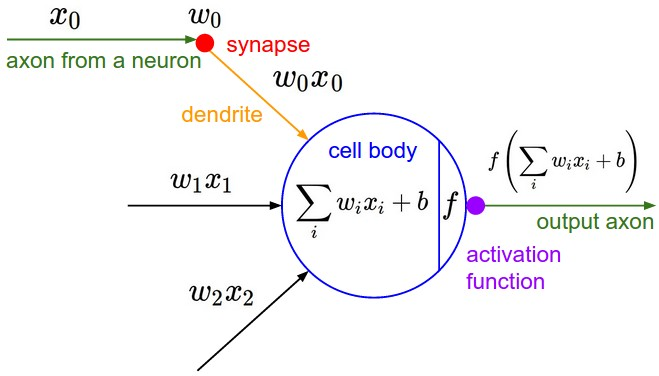

In [ ]:
 # inputs x1,x2

x1 = Value(2.0, label='x1')
x2 = Value(0.0, label='x2')

# weights w1,w2
w1 = Value(-3.0, label='w1')
w2 = Value(1.0, label='w2')

# bias of the neuron
b = Value(6.8813735870195432, label='b')

# x1*w1 + x2*w2 + b
x1w1 = x1*w1; x1w1.label = 'x1*w1'
x2w2 = x2*w2; x2w2.label = 'x2*w2'
x1w1x2w2 = x1w1 + x2w2; x1w1x2w2.label = 'x1*w1 + x2*w2'
n = x1w1x2w2 + b; n.label = 'n'

# activation function
o = n.tanh(); o.label = 'o'
#draw_dot(o)

In [ ]:
# o = tanh(n)
# do/dn = 1 - tanh(n)** = 1 - o**2
# https://en.wikipedia.org/wiki/Hyperbolic_functions

# o.grad = 1.0

# o._backward()
# n._backward()
# b._backward()
# x1w1x2w2._backward()
# x1w1._backward()
# x2w2._backward()
# draw_dot(o)

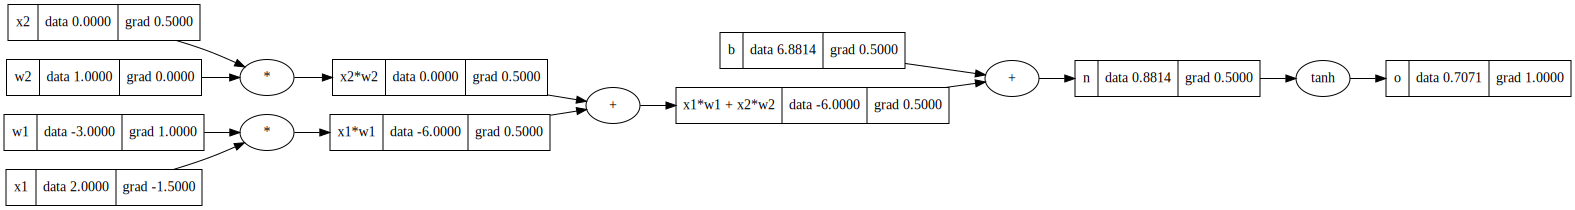

In [ ]:
o.grad = 1.0
o.backward()
draw_dot(o)

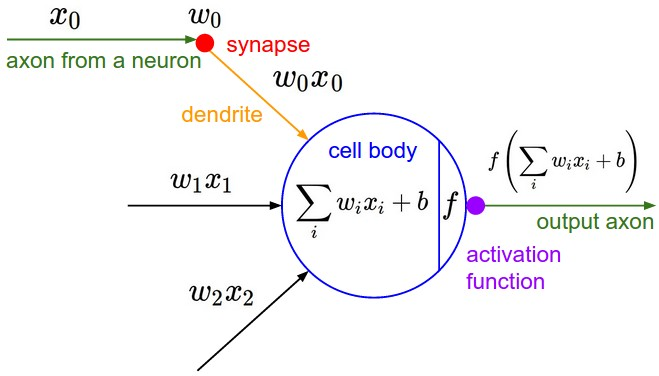

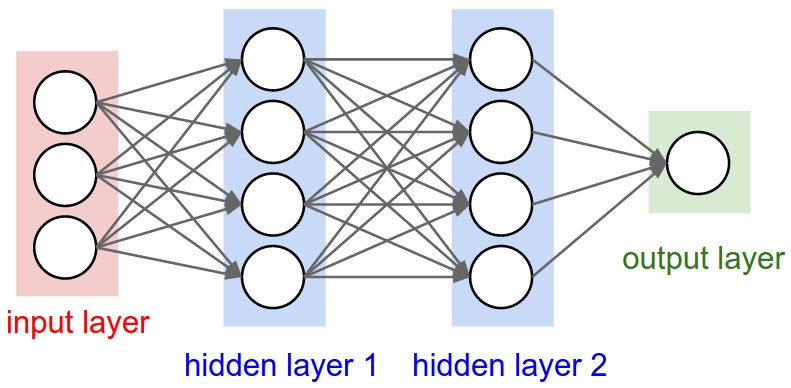

In [ ]:
# MLP

class Neuron:

  def __init__(self, num_inputs):
    self.weights = [Value(random.uniform(-1,1)) for _ in range(num_inputs)]
    self.bias = Value(random.uniform(-1,1))

  # n = Neuron(2)
  # n(x)
  def __call__(self, x):
    # weight * input + bias
    act = sum(wi*xi for wi,xi in zip(self.weights, x)) + self.bias
    out = act.tanh()
    return out

  def parameters(self):
    return self.weights + [self.bias]

class Layer:

  def __init__(self, num_inputs, num_outputs):
    self.neurons = [Neuron(num_inputs) for _ in range(num_outputs)]

  # Each neuron <- x
  def __call__(self, x):
    outs = [neuron(x) for neuron in self.neurons]
    return outs[0] if len(outs) == 1 else outs

  def parameters(self):
    return [p for neuron in self.neurons for p in neuron.parameters()]

class MLP:

  def __init__(self, num_inputs, layer_sizes):
    # convenience
    sizes = [num_inputs] + layer_sizes
    self.layers = [Layer(sizes[i],sizes[i+1]) for i in range(len(layer_sizes))]

  def __call__(self, x):
    for layer in self.layers:
      layer_out = layer(x)
      x = layer_out
    return layer_out

  def parameters(self):
    return [p for layer in self.layers for p in layer.parameters()]


# Test
x = [2.0, 3.0, -1.0]
n = MLP(3, [4,4,1])
n(x)



Value(data=0.5200302409742567)

In [ ]:
xs = [
  [2.0, 3.0, -1.0],
  [3.0, -1.0, 0.5],
  [0.5, 1.0, 1.0],
  [1.0, 1.0, -1.0],
]
ys = [1.0, -1.0, -1.0, 1.0] # desired targets

y_predictions = [n(x) for x in xs]

loss = sum((y_pred - y_expe)**2 for y_pred, y_expe in zip(y_predictions, ys))

loss.backward()
loss
#draw_dot(loss)



Value(data=2.4126719290864114)

In [ ]:
print(n.layers[0].neurons[0].weights[0].data)
print(n.layers[0].neurons[0].weights[0].grad)

-0.23725423139771107
0.22641141448100727


In [ ]:
for p in n.parameters():
  p.data += -0.01 * p.grad

print(n.layers[0].neurons[0].weights[0].data)
print(n.layers[0].neurons[0].weights[0].grad)


-0.2437362829016701
0.20986524600729553


In [ ]:
y_predictions = [n(x) for x in xs]

loss = sum((y_pred - y_expe)**2 for y_pred, y_expe in zip(y_predictions, ys))


loss

Value(data=1.7657247027429905)

In [ ]:
for p in n.parameters():
  p.grad = 0.0
loss.backward()